# Cargamos librerías

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Cargamos DB

In [3]:
# Cargar y preparar dataset
df = pd.read_csv("HDHI_Admission_data.csv")

# Convertir columna a datetime de manera automática
df["D.O.A"] = pd.to_datetime(df["D.O.A"], errors="coerce")

# Crear conteo diario de pacientes
daily = df.groupby(df["D.O.A"].dt.date).size().reset_index(name="patients")
daily["D.O.A"] = pd.to_datetime(daily["D.O.A"])

# Ordenar por fecha
daily = daily.sort_values("D.O.A").reset_index(drop=True)

print(daily.head(20))   # muestra las primeras 20 filas

        D.O.A  patients
0  2017-01-04         1
1  2017-01-10         2
2  2017-01-11         2
3  2017-01-12        11
4  2017-02-04         2
5  2017-02-10         5
6  2017-02-11         2
7  2017-02-12         9
8  2017-03-10         8
9  2017-03-11         8
10 2017-03-12         7
11 2017-04-01        29
12 2017-04-02        13
13 2017-04-03        26
14 2017-04-04        20
15 2017-04-05         7
16 2017-04-06        11
17 2017-04-07         6
18 2017-04-08        11
19 2017-04-09         8


In [4]:
# CALCULAR MEDIA DE PACIENTES NUEVOS DIARIOS
# Crear rango completo de fechas
rango_completo = pd.date_range(
    start=daily["D.O.A"].min(),
    end=daily["D.O.A"].max(),
    freq="D"
)

# Reindexar para incluir días con 0 pacientes
daily_full = (
    daily.set_index("D.O.A")
         .reindex(rango_completo, fill_value=0)
         .rename_axis("D.O.A")
         .reset_index()
)

# Calcular media real
media_real = daily_full["patients"].mean()

print("Media real de pacientes nuevos por día:", round(media_real, 2))

# Si no contasemso los dias sin ingreso
print("Media de pacientes nuevos por día (solo dias con ingresos):",daily["patients"].mean())

Media real de pacientes nuevos por día: 9.49
Media de pacientes nuevos por día (solo dias con ingresos): 13.895460797799174


In [5]:
# Variables temporales
daily_full["dayofweek"] = daily_full["D.O.A"].dt.dayofweek
daily_full["month"] = daily_full["D.O.A"].dt.month
daily_full["day"] = daily_full["D.O.A"].dt.day
daily_full["weekofyear"] = daily_full["D.O.A"].dt.isocalendar().week.astype(int)

# Lags reales (ahora sí son días consecutivos)
# lag_1 Número de pacientes del día anterior
# lag_7 número de pacientes hace 7 días (misma semana, patrón semanal)
daily_full["lag_1"] = daily_full["patients"].shift(1)
daily_full["lag_7"] = daily_full["patients"].shift(7)

# Rolling correctamente definido
daily_full["rolling_mean_7"] = daily_full["patients"].rolling(window=7).mean()

# Eliminar filas iniciales con NaN generados por los lags
daily_full = daily_full.dropna().reset_index(drop=True)

# Dividimos en X e y train y test

In [6]:
features = [
    "dayofweek",
    "month",
    "day",
    "weekofyear",
    "lag_1",
    "lag_7",
    "rolling_mean_7"
]

# Después de calcular lags y dropna
X = daily_full.drop(columns=["patients", "D.O.A"])
y = daily_full["patients"]

# Split temporal (MUY IMPORTANTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

# Evaluamos el modelo

In [7]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Evaluar
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RESULTADOS:")
print(f"MAE: {mae:.2f} pacientes")
print(f"RMSE: {rmse:.2f} pacientes")

RESULTADOS:
MAE: 1.17 pacientes
RMSE: 3.48 pacientes


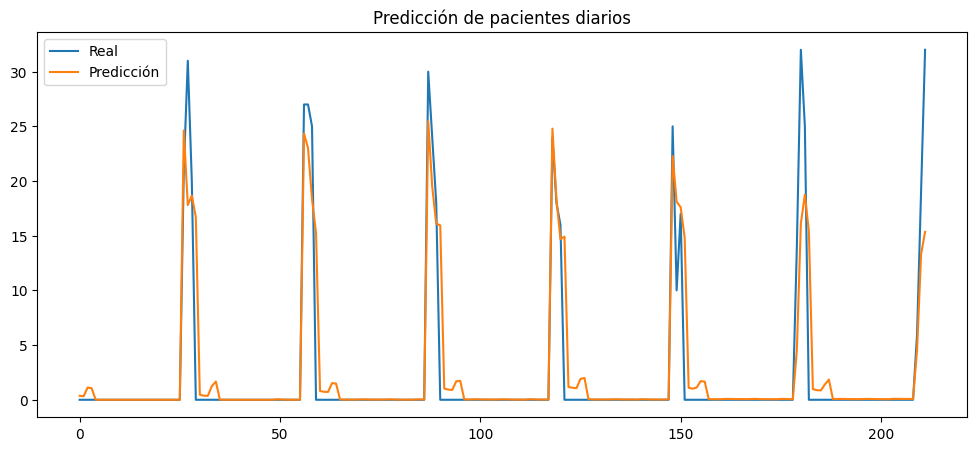

In [9]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(predictions, label="Predicción")
plt.legend()
plt.title("Predicción de pacientes diarios")
plt.show()

# SI NO USAMOS EL DAILYFULL

# MODELO LIGHTGBM

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor

In [59]:
# Cargar datos
df = pd.read_csv("HDHI_Admission_data.csv")

# Convertimos la columna a tipo datetime para poder manipular fechas fácilmente.
df["D.O.A"] = pd.to_datetime(df["D.O.A"], errors="coerce")

# Conteo diario real ( DataFrame con columnas: D.O.A y patients.)
daily_counts = df.groupby(df["D.O.A"].dt.date).size().reset_index(name="patients")
daily_counts["D.O.A"] = pd.to_datetime(daily_counts["D.O.A"])

# Crear calendario completo ( creamos rango continuo que incluye días donde no hubo pacientes, que antes no estaban en los datos.)
all_dates = pd.date_range(
    start=daily_counts["D.O.A"].min(),
    end=daily_counts["D.O.A"].max(),
    freq="D"
)
daily = pd.DataFrame({"D.O.A": all_dates})

# Merge con conteos reales
daily = daily.merge(daily_counts, on="D.O.A", how="left")

# Rellenar días sin pacientes (Los días que no aparecen (NaN) los rellenamos con 0) 
daily["patients"] = daily["patients"].fillna(0)

# Ordenar, aseguramos que los datos estén en orden temporal.
daily = daily.sort_values("D.O.A").reset_index(drop=True)

In [60]:
#  Variables temporales 
# Extraemos características de la fecha que ayudan a LightGBM a aprender estacionalidad
daily["dayofweek"] = daily["D.O.A"].dt.dayofweek
daily["month"] = daily["D.O.A"].dt.month
daily["day"] = daily["D.O.A"].dt.day
daily["weekofyear"] = daily["D.O.A"].dt.isocalendar().week.astype(int)
daily["is_weekend"] = daily["dayofweek"].isin([5,6]).astype(int)

# Lags y rolling (sobre serie completa): captura patrones recientes y semanales
for lag in [1,2,3,7,14]:
    daily[f"lag_{lag}"] = daily["patients"].shift(lag)

# suaviza la serie y reduce ruido
daily["rolling_mean_3"] = daily["patients"].rolling(3).mean()
daily["rolling_mean_7"] = daily["patients"].rolling(7).mean()
daily["rolling_mean_14"] = daily["patients"].rolling(14).mean()

# Diferencias: permite detectar tendencias o picos
daily["diff_1"] = daily["lag_1"] - daily["lag_2"]
daily["diff_7"] = daily["lag_1"] - daily["lag_7"]

# Eliminar primeras filas con NaN porque no hay datos previos suficientes para los lags o rolling.
daily = daily.dropna().reset_index(drop=True)

# Features que usará LightGBM para predecir y target que queremos predecir (pacientes diarios).
features = [
    "dayofweek", "month", "day", "weekofyear", "is_weekend",
    "lag_1","lag_2","lag_3","lag_7","lag_14",
    "rolling_mean_3","rolling_mean_7","rolling_mean_14",
    "diff_1","diff_7"
]

X = daily[features]
y = daily["patients"]

# Construimos y entrenamos el modelo

In [61]:
# Split temporal ( shuffle=False mantiene el orden temporal, esencial para series temporales)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Modelo LightGBM optimizado
model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=15,
    num_leaves=63,
    min_child_samples=2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Predicción de pacientes diarios sobre el conjunto de test.
predictions = model.predict(X_test)

# Evaluación del modelo
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\nRESULTADOS:")
print(f"MAE: {mae:.2f} pacientes")
print(f"RMSE: {rmse:.2f} pacientes")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000776 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 840, number of used features: 15
[LightGBM] [Info] Start training from score 11.458333
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

RESULTADOS:
MAE: 0.83 pacientes
RMSE: 2.13 pacientes


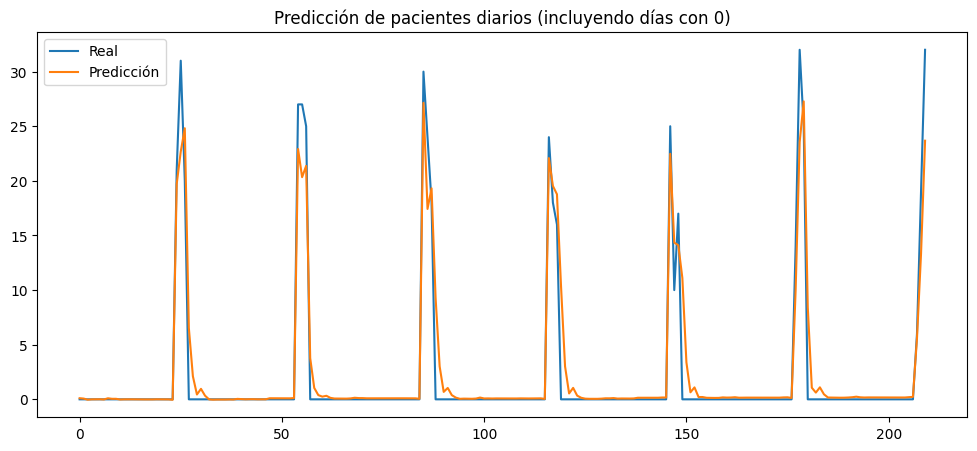

In [62]:
#  Visualización

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(predictions, label="Predicción")
plt.legend()
plt.title("Predicción de pacientes diarios (incluyendo días con 0)")
plt.show()

In [63]:
import pandas as pd
import pprint

print("--- 1. ANATOMÍA DEL MODELO ---")
# Número de árboles construidos
print(f"Árboles construidos: {model.booster_.num_trees()}")

print("\n--- 2. PARÁMETROS DEL MODELO ---")
# Todos los parámetros configurados
parametros = model.get_params()
print("Algunos parámetros clave que usó LightGBM:")
print(f"- max_depth: {parametros.get('max_depth')}")
print(f"- num_leaves: {parametros.get('num_leaves')}")
print(f"- learning_rate: {parametros.get('learning_rate')}")
print(f"- n_estimators: {parametros.get('n_estimators')}")
print(f"- min_child_samples: {parametros.get('min_child_samples')}")
print(f"- subsample: {parametros.get('subsample')}")
print(f"- colsample_bytree: {parametros.get('colsample_bytree')}")


--- 1. ANATOMÍA DEL MODELO ---
Árboles construidos: 2000

--- 2. PARÁMETROS DEL MODELO ---
Algunos parámetros clave que usó LightGBM:
- max_depth: 15
- num_leaves: 63
- learning_rate: 0.03
- n_estimators: 2000
- min_child_samples: 2
- subsample: 0.8
- colsample_bytree: 0.8
